In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 예시 데이터: 서울 강수량 데이터 (실제 데이터로 교체 필요)
# 날짜, 강수량 포함된 df 생성
dates = pd.date_range(start="1995-01-01", end="2024-12-31", freq='D')
np.random.seed(42)
df = pd.DataFrame({
    "날짜": dates,
    "강수량": np.abs(np.random.normal(loc=3, scale=5, size=len(dates)))
})

# 날짜 컬럼 datetime 변환 (혹시나 텍스트일 경우)
df["날짜"] = pd.to_datetime(df["날짜"])

# ✅ 24절기 정의 (월-일 기준, 연도는 나중에 붙임)
solar_terms = {
    "입춘": "02-04", "우수": "02-19", "경칩": "03-05", "춘분": "03-20",
    "청명": "04-04", "곡우": "04-20", "입하": "05-05", "소만": "05-21",
    "망종": "06-05", "하지": "06-21", "소서": "07-07", "대서": "07-22",
    "입추": "08-07", "처서": "08-23", "백로": "09-07", "추분": "09-23",
    "한로": "10-08", "상강": "10-23", "입동": "11-07", "소설": "11-22",
    "대설": "12-07", "동지": "12-22", "소한": "01-05", "대한": "01-20"
}

# ✅ 절기별 ±3일 강수량 평균 추출 함수
def extract_term_rain(df, term_dict, window=3):
    results = []
    for term, md in term_dict.items():
        for year in df["날짜"].dt.year.unique():
            try:
                date_str = f"{year}-{md}"
                if term in ["소한", "대한"]:  # 1월 절기는 다음 해로 보정
                    if year == df["날짜"].dt.year.min():
                        continue  # 1월은 이전 연도 데이터가 없을 수 있음
                term_date = pd.to_datetime(date_str)
            except:
                continue

            mask = (df["날짜"] >= term_date - pd.Timedelta(days=window)) & \
                   (df["날짜"] <= term_date + pd.Timedelta(days=window))
            subset = df[mask]
            if not subset.empty:
                results.append({
                    "절기": term,
                    "연도": year,
                    "강수량": subset["강수량"].mean()
                })
    return pd.DataFrame(results)

# ✅ 절기별 강수량 데이터 생성
term_rain_df = extract_term_rain(df, solar_terms)

# ✅ 시기 구분 추가
term_rain_df["시기"] = term_rain_df["연도"].apply(
    lambda y: "과거(1995–1999)" if 1995 <= y <= 1999 else ("최근(2020–2024)" if 2020 <= y <= 2024 else "기타")
)
term_rain_df = term_rain_df[term_rain_df["시기"] != "기타"]

# ✅ 절기 순서를 유지하기 위한 카테고리 설정
term_order = list(solar_terms.keys())
term_rain_df["절기"] = pd.Categorical(term_rain_df["절기"], categories=term_order, ordered=True)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # macOS
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스나 colab 등

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

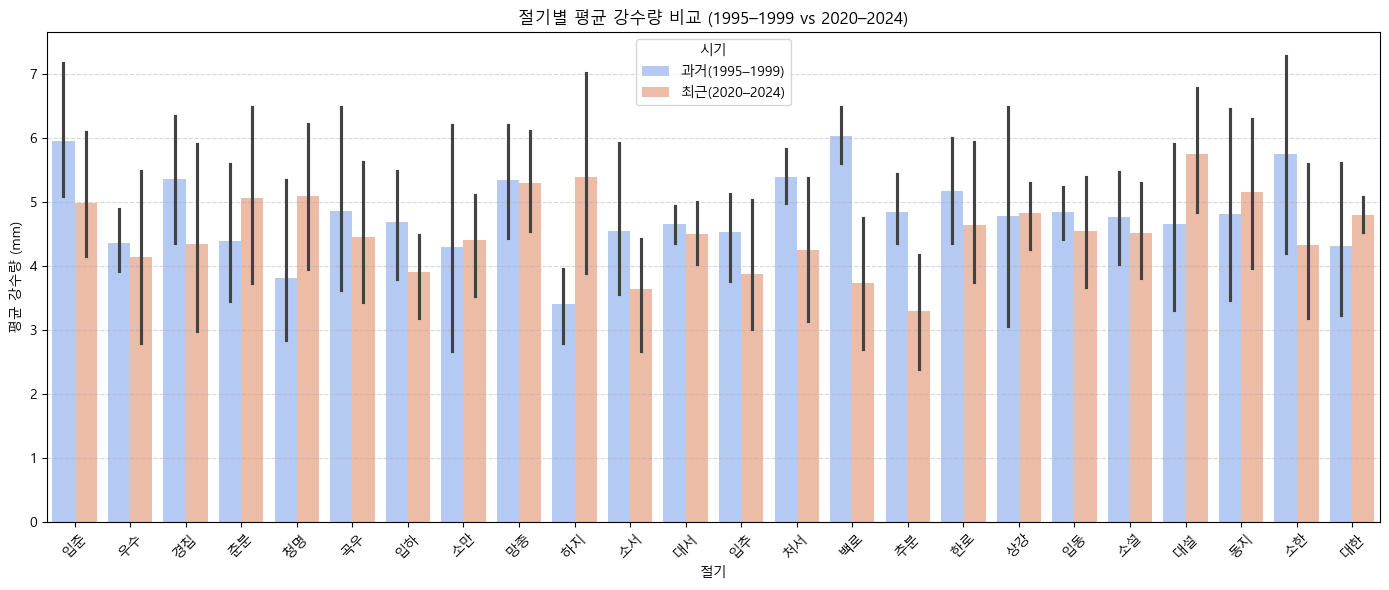

In [5]:
plt.figure(figsize=(14, 6))
sns.barplot(data=term_rain_df, x="절기", y="강수량", hue="시기", palette="coolwarm")
plt.title("절기별 평균 강수량 비교 (1995–1999 vs 2020–2024)")
plt.ylabel("평균 강수량 (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


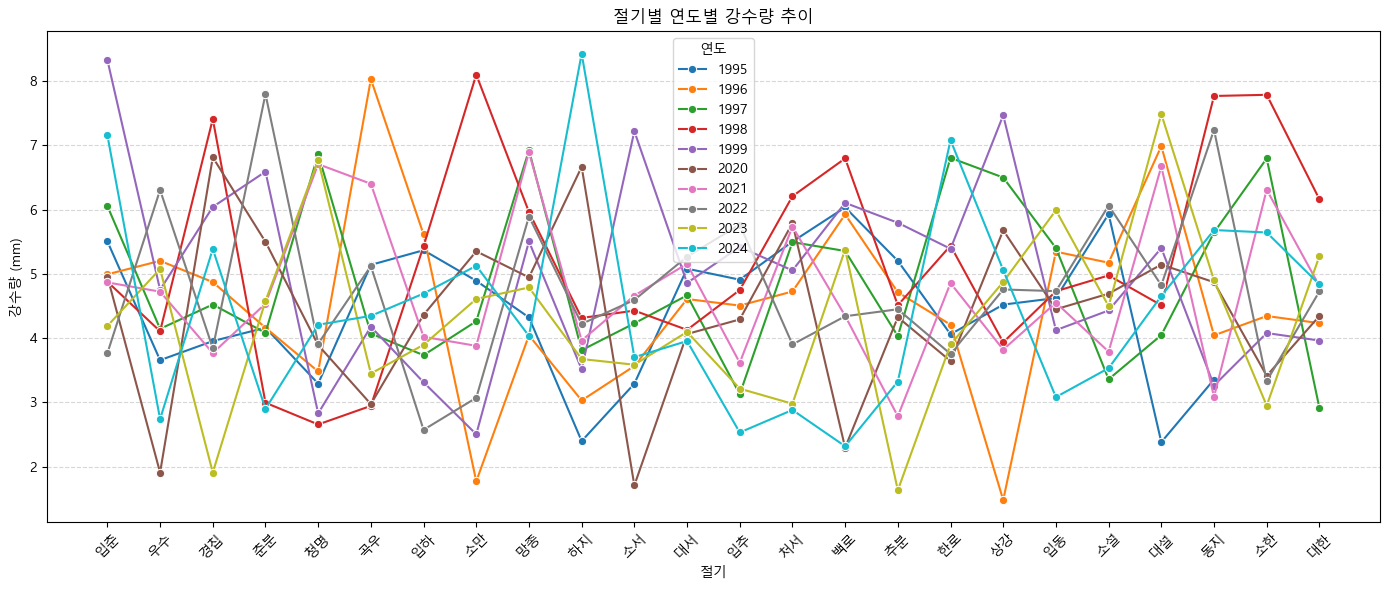

In [6]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=term_rain_df, x="절기", y="강수량", hue="연도", marker="o", palette="tab10")
plt.title("절기별 연도별 강수량 추이")
plt.ylabel("강수량 (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


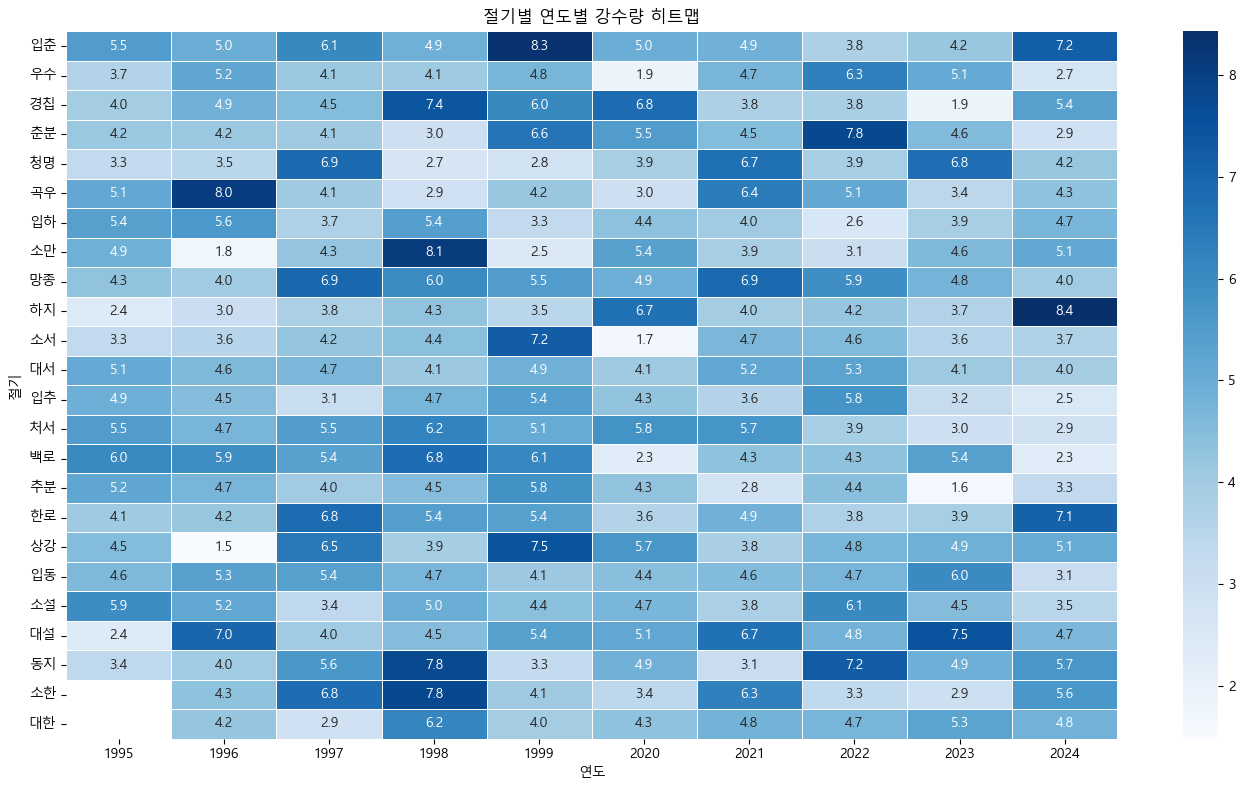

In [7]:
pivot_df = term_rain_df.pivot(index="절기", columns="연도", values="강수량").reindex(term_order)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("절기별 연도별 강수량 히트맵")
plt.ylabel("절기")
plt.xlabel("연도")
plt.tight_layout()
plt.show()


In [8]:
# 주요 강수절기만 필터링
focus_terms = ["곡우", "소서", "대설"]
rain_focus_df = term_rain_df[term_rain_df["절기"].isin(focus_terms)]


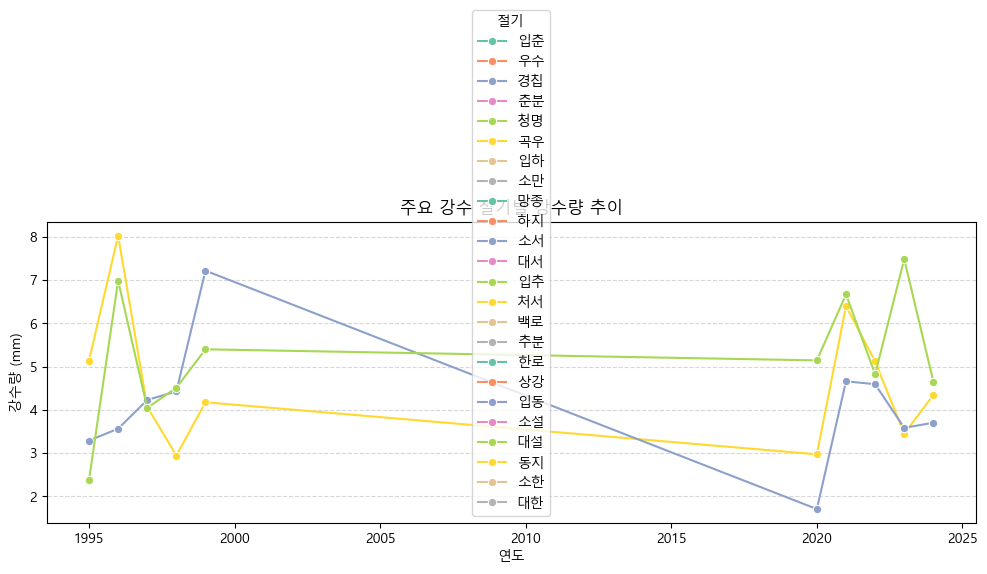

In [9]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=rain_focus_df, x="연도", y="강수량", hue="절기", marker="o", palette="Set2")
plt.title("주요 강수 절기별 강수량 추이")
plt.ylabel("강수량 (mm)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18932\2757224147.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain_focus_df["이상강수"] = rain_focus_df.apply(
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18932\2757224147.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anomalies_count, x="절기", y="이상강수연도수", palette="coolwarm")


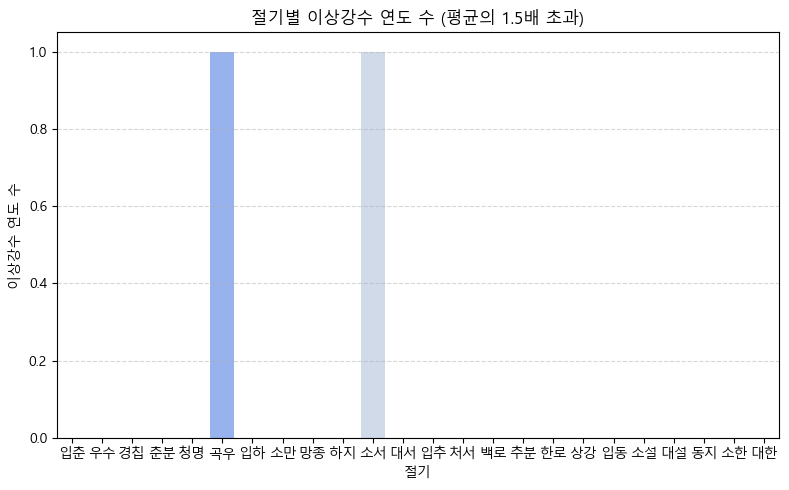

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 1. 강수량 중심 절기만 필터링
focus_terms = ["곡우", "소서", "대설"]
rain_focus_df = term_rain_df[term_rain_df["절기"].isin(focus_terms)]

# ✅ 2. 이상강수 기준 설정: 절기별 평균의 1.5배
thresholds = (
    rain_focus_df.groupby("절기", observed=True)["강수량"]
    .mean()
    .apply(lambda x: x * 1.5)
    .to_dict()
)

# ✅ 3. 이상강수 여부 플래그 컬럼 추가
rain_focus_df["이상강수"] = rain_focus_df.apply(
    lambda row: row["강수량"] > thresholds.get(row["절기"], np.inf),
    axis=1
)

# ✅ 4. 절기별 이상강수 연도 수 집계
anomalies_count = (
    rain_focus_df[rain_focus_df["이상강수"]]
    .groupby("절기", observed=True)["연도"]
    .count()
    .reset_index(name="이상강수연도수")
)

# ✅ 5. 시각화
plt.figure(figsize=(8, 5))
sns.barplot(data=anomalies_count, x="절기", y="이상강수연도수", palette="coolwarm")
plt.title("절기별 이상강수 연도 수 (평균의 1.5배 초과)")
plt.ylabel("이상강수 연도 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18932\1669610706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  term_rain_df.groupby(["절기", "시기"])["강수량"]
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18932\1669610706.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivoted.index, y=pivoted["강수량변화율"], palette="Spectral")


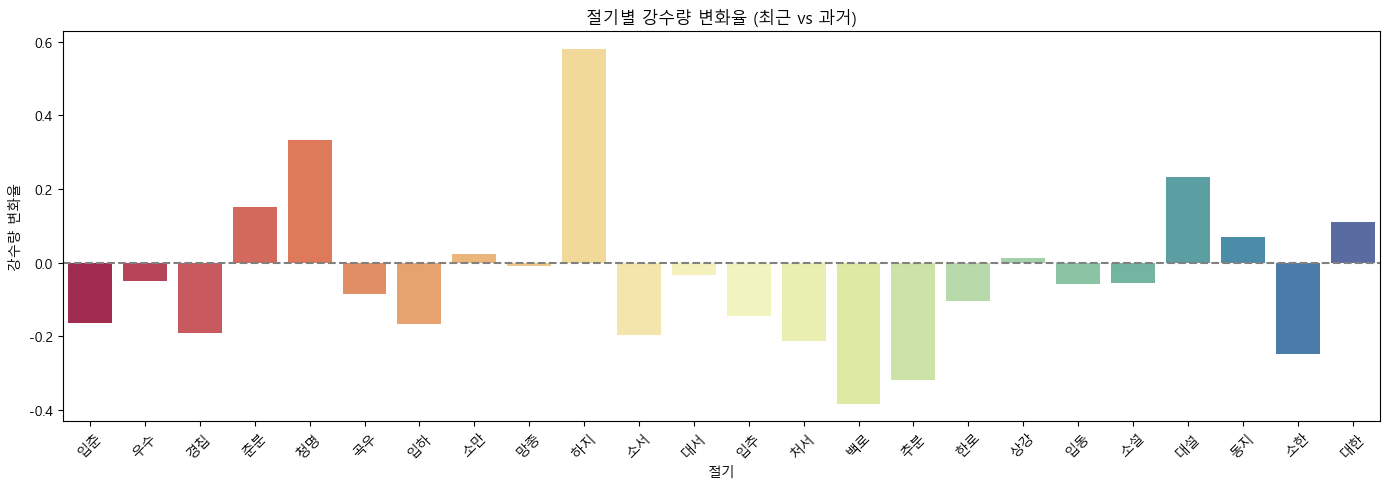

In [11]:
# 과거 평균 (1995–1999), 최근 평균 (2020–2024) 절기별로 계산
pivoted = (
    term_rain_df.groupby(["절기", "시기"])["강수량"]
    .mean()
    .reset_index()
    .pivot(index="절기", columns="시기", values="강수량")
)

# 변화율 계산: (최근 - 과거) / 과거
pivoted["강수량변화율"] = (
    (pivoted["최근(2020–2024)"] - pivoted["과거(1995–1999)"]) /
    pivoted["과거(1995–1999)"]
)

# NaN이나 무한대 제거
pivoted = pivoted.replace([np.inf, -np.inf], np.nan).dropna()

# 시각화
plt.figure(figsize=(14, 5))
sns.barplot(x=pivoted.index, y=pivoted["강수량변화율"], palette="Spectral")
plt.axhline(0, color="gray", linestyle="--")
plt.title("절기별 강수량 변화율 (최근 vs 과거)")
plt.ylabel("강수량 변화율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
# 강수량 중심 절기 목록
focus_terms = ["우수", "춘분", "청명", "곡우", "망종", "소서", "대서", "백로", "추분", "소설", "대설"]

# 절기 필터링
filtered_df = term_rain_df[term_rain_df["절기"].isin(focus_terms)]

# 절기 순서 지정
filtered_term_order = [term for term in term_order if term in focus_terms]
filtered_df["절기"] = pd.Categorical(filtered_df["절기"], categories=filtered_term_order, ordered=True)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18932\3845503146.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["절기"] = pd.Categorical(filtered_df["절기"], categories=filtered_term_order, ordered=True)


In [18]:
# 시기별 평균 강수량 계산
grouped_rain = (
    filtered_df.groupby(["절기", "시기"], observed=True)["강수량"]
    .mean()
    .reset_index()
)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18932\2865666488.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=grouped_rain, x="절기", y="강수량", hue="시기", palette="coolwarm", ci=None)


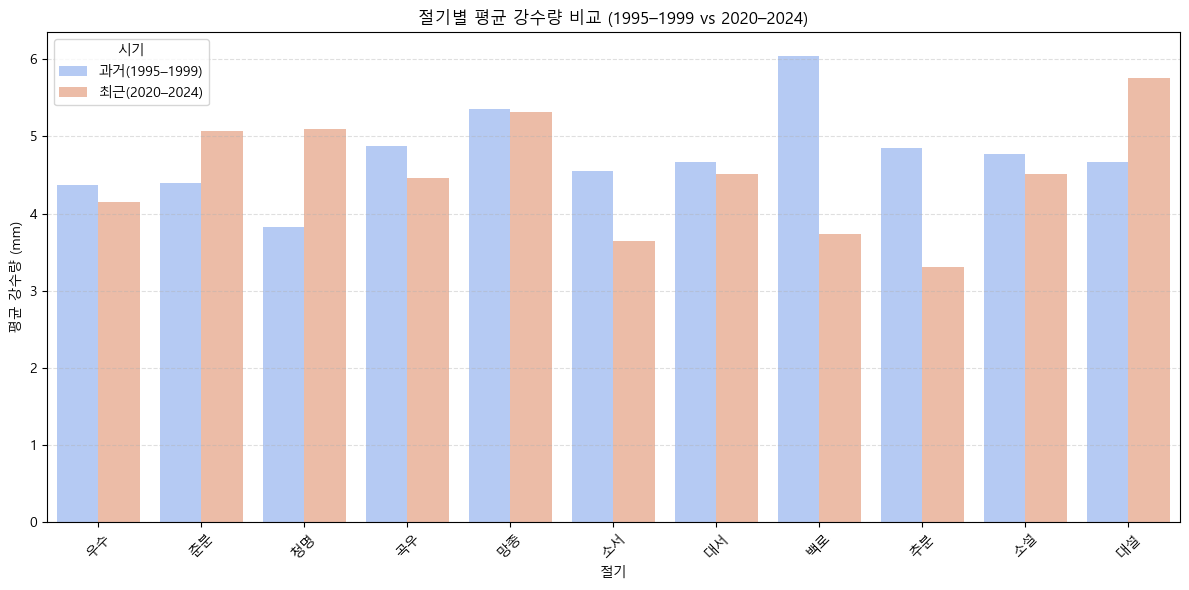

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_rain, x="절기", y="강수량", hue="시기", palette="coolwarm", ci=None)

plt.title("절기별 평균 강수량 비교 (1995–1999 vs 2020–2024)")
plt.ylabel("평균 강수량 (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
